In [139]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from DTOL import Hedge, AdaHedge

# PARAMETERS FOR THE EXPERIMENTS
I = 9                                                # Number of segments (I segments of lengths 1, 2, 4, ..., 2^(I-1)) for last setting
T = 2**I - 1                                         # Number of rounds
epsilon = 0.1                                        # Gap between the best expert and the others in the stochastic setting
K = 20                                                      # Number of experts
worstCaseEta = math.sqrt(2*math.log(K)/T)                   # Probability of loss for the worst expert in the stochastic setting
etas = [worstCaseEta, worstCaseEta*10, worstCaseEta*1000]   # Different eta values to test for Hedge


In [140]:
# GRAPHIC HELPERS

# Function to plot the cumulative loss curves of AdaHedge and Hedge algorithms
# AdaLosses: list of cumulative losses for AdaHedge over T rounds
# HedgeLosses: list of lists, where each inner list contains cumulative losses for a single run of the Hedge algorithm 
# over T rounds with different etas
def plotPolylineRiskCurve(AdaLosses, HedgeLosses, etas, title):
    plt.figure()
    
    for i in range(len(HedgeLosses)):
        plt.plot(HedgeLosses[i], linestyle='dashed', label=f'Hedge eta={float(etas[i]):.3f}')
    plt.plot(AdaLosses, label='AdaHedge')
    
    plt.title(title)
    plt.xlabel('Round')
    plt.ylabel('Cumulative Loss')
    plt.grid()
    plt.legend()
    plt.show()

def plotBarCumulativeLosses(AdaCumulativeLoss, HedgeCumulativeLoss, etas, title):
    plt.figure(figsize=(8, 6))
    
    x = np.arange(len(etas) + 1)  # Number of bars (Hedge etas + AdaHedge)
    losses = HedgeCumulativeLoss + [AdaCumulativeLoss]  # Cumulative losses for Hedge and AdaHedge
    
    # Bar with different colors for Hedge and AdaHedge
    bars = plt.bar(x, losses, alpha=0.5, width=0.5, color=['blue']*len(etas) + ['orange'])
    plt.xticks(x, [f'Hedge eta={float(e):.3f}' for e in etas] + ['AdaHedge'])

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(losses)*0.01), 
                round(yval, 2), ha='center', va='bottom', fontsize=9)
    
    plt.title(title)
    plt.ylabel('Cumulative Regret at T')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [141]:
import numpy as np

def average_benchmark(n_runs):
    def decorator(func):
        def wrapper(lossGenerator, etas, *args, **kwargs):
            sum_ada = None
            sum_hedge = None
            avg_ada_eta = 0

            for i in range(n_runs):
                expertLosses = lossGenerator(K, T)
                ada_res, hedge_res, ada_eta = func(expertLosses, etas, *args, **kwargs)
                avg_ada_eta += ada_eta

                if sum_ada is None:
                    sum_ada = np.array(ada_res)
                    sum_hedge = np.array(hedge_res)
                else:
                    sum_ada += np.array(ada_res)
                    sum_hedge += np.array(hedge_res)

            avg_ada = (sum_ada / n_runs).tolist()
            avg_hedge = (sum_hedge / n_runs).tolist()
            
            return avg_ada, avg_hedge, avg_ada_eta / n_runs
        return wrapper
    return decorator


def computeCumLosses(expertLosses, etas):
    adaCumLoss = []
    hedgeCumLoss = [[] for _ in etas]

    # --- AdaHedge ---
    adaHedge = AdaHedge(K=K)
    for t in range(T):
        probs = adaHedge.get_probabilities()
        round_loss = sum(expertLosses[t][i] * probs[i] for i in range(K))
        
        adaCumLoss.append((adaCumLoss[-1] if t > 0 else 0.0) + round_loss)
        
        adaHedge.update(expertLosses[t])

    # --- Hedge (con vari valori di eta) ---
    for (i, e) in enumerate(etas):
        hedge = Hedge(K, e)
        for t in range(T):
            probs = hedge.get_probabilities()
            round_loss = sum(expertLosses[t][j] * probs[j] for j in range(K))
            
            
            hedgeCumLoss[i].append((hedgeCumLoss[i][t-1] if t > 0 else 0.0) + round_loss)
            
            hedge.update(expertLosses[t])
    
    return adaCumLoss, hedgeCumLoss, adaHedge.get_eta()


@average_benchmark(n_runs=20)
def benchmarkCumulativeLosses(expertLosses, etas):
    return computeCumLosses(expertLosses, etas)


def getCumulativeLosses(expertLosses):
    cum_losses = []
    for t in range(T):
        cum_losses_at_time_t = []
        for k in range(K):
            if t > 0:
                l = cum_losses[t - 1][k] + expertLosses[t][k]
            else:
                l = expertLosses[t][k]
            cum_losses_at_time_t.append(l)
        cum_losses.append(cum_losses_at_time_t)
    return cum_losses


@average_benchmark(n_runs=20)
def benchmarkCumulativeRegret(expertLosses, etas):
    adaLosses, hedgeLosses, ada_eta = computeCumLosses(expertLosses, etas)
    
    expert_cum = getCumulativeLosses(expertLosses)
    
    bestExpertCumLoss = [] 
    for t in range(T):
        best_loss_at_t = np.min(expert_cum[t])
        bestExpertCumLoss.append(best_loss_at_t)
    
    adaRegret = [adaLosses[t] - bestExpertCumLoss[t] for t in range(T)]
    
    hedgeRegret = []
    for i in range(len(etas)):
        h_regret = [hedgeLosses[i][t] - bestExpertCumLoss[t] for t in range(T)]
        hedgeRegret.append(h_regret)
        
    return adaRegret, hedgeRegret, ada_eta

In [142]:
# Stochastic Setting
# Experts losses in [0,1] and every expert loss is randomly generated from a bernoulli 
# distribution with parameter p = 0.3 for the first expert and p = 0.5 for the others.

def stochastic_losses(K,T):
    expertLosses = []
    expertLosses.append(scipy.stats.bernoulli.rvs(0.3, size=T))
    for _ in range(K-1):
        expertLosses.append(scipy.stats.bernoulli.rvs(0.5, size=T))
    

    expertLosses = np.array(expertLosses).transpose() 
    return expertLosses

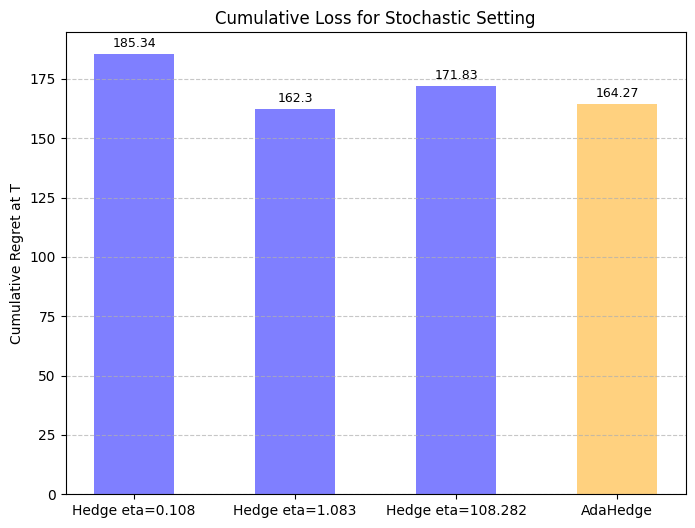

Average eta for AdaHedge in stochastic setting: 0.85


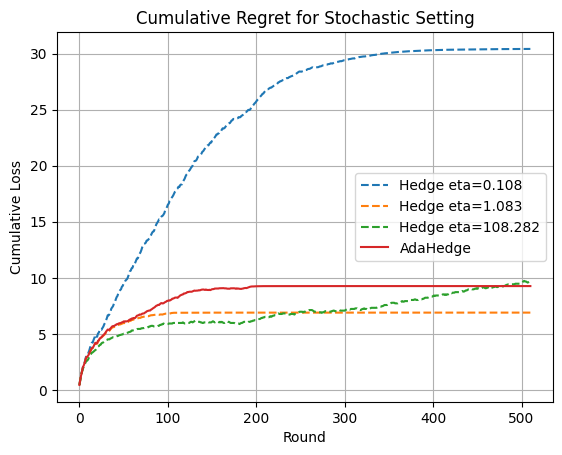

In [143]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(stochastic_losses, etas)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Stochastic Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(stochastic_losses, etas)
print("Average eta for AdaHedge in stochastic setting:", AdaEta)
plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Stochastic Setting")


In [144]:
# Adversarial Setting
# The best expert change every round.

def adversarial_losses(K,T):
    expertLosses = np.zeros((T, K)) # Reset expert losses
    for t in range(T):
        expert = random.randint(0, K-1) # Randomly select the best expert for this round
        expertLosses[t][expert] = 0 # Best expert has loss 0
        for i in range(K):
            if i != expert:
                expertLosses[t][i] = 1.0 # Other experts have loss 1.0

    return expertLosses


Average eta for AdaHedge in adversarial setting: 0.575


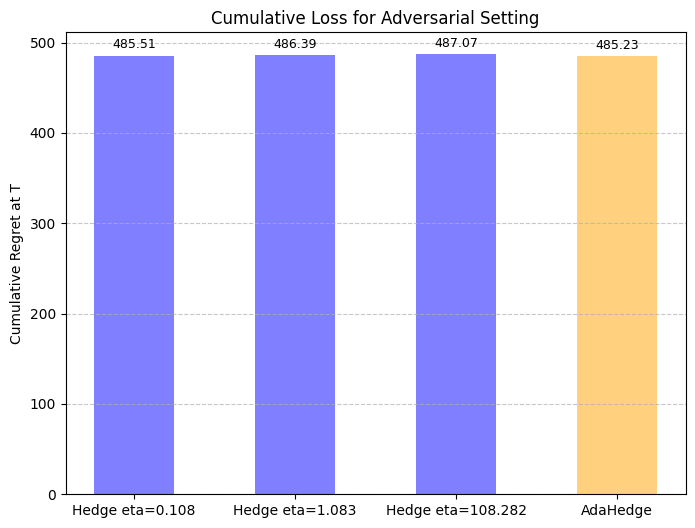

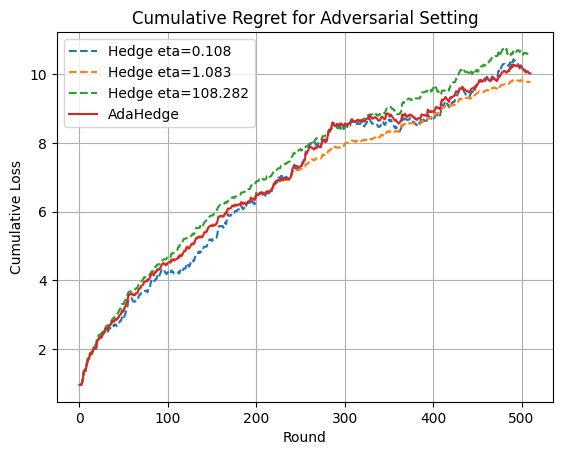

In [145]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(adversarial_losses, etas)
print("Average eta for AdaHedge in adversarial setting:", AdaEta)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Adversarial Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(adversarial_losses, etas)
plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Adversarial Setting")


In [146]:
# Low Gap Setting
# 1 expert has probability of loss 0.49 and the others have probability of loss 0.5.

def low_gap_losses(K,T):
    expertLosses = []
    for _ in range(K-1):
        expertLosses.append(scipy.stats.bernoulli.rvs(0.5, size=T))
        expertLosses.append(scipy.stats.bernoulli.rvs(0.5 - epsilon, size=T))

    expertLosses = np.array(expertLosses).transpose() # Transpose to get losses in the format expertLosses[t][i]
    return expertLosses



Average eta for AdaHedge in low gap setting: 0.3125


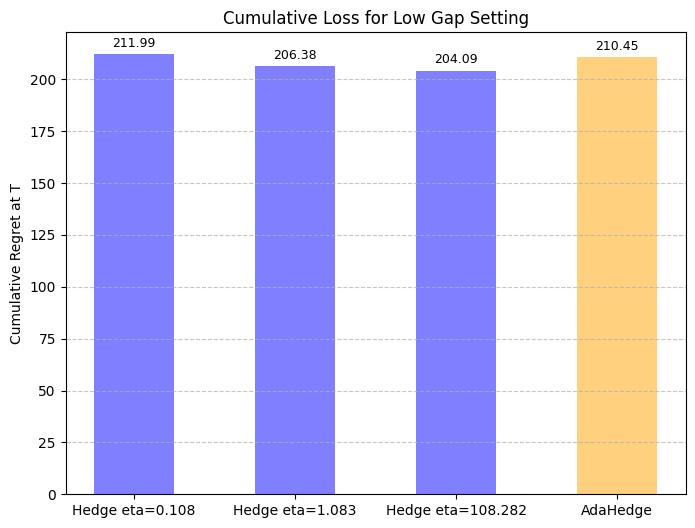

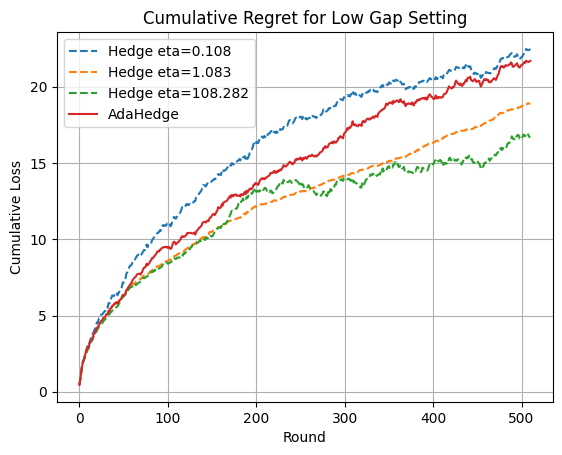

In [147]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(low_gap_losses, etas)
print("Average eta for AdaHedge in low gap setting:", AdaEta)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Low Gap Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(low_gap_losses, etas)

plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Low Gap Setting")

In [ ]:
# exponential segment Setting
# at every segment m_i = 2^i steps, one expert has probability of loss 0.5 - epsilon and the others have probability of loss 0.5.
# the expert with probability of loss 0.5 - epsilon is randomly selected at the beginning of each segment.



def exponential_segment_setting(K, T):
    expertLosses = []
    kS = 0
    for i in range(I):
        kS = random.randint(0, K-1) # Randomly select the best expert for this segment
        
        for m in range(2**i):
            round_losses = []
            for k in range(K):
                if k == kS:
                    loss = scipy.stats.bernoulli.rvs(0.5 - epsilon)
                else:
                    loss = scipy.stats.bernoulli.rvs(0.5)
                round_losses.append(loss)
            
            expertLosses.append(round_losses)

    return np.array(expertLosses)

Average eta for AdaHedge in exponential segment setting: 0.275


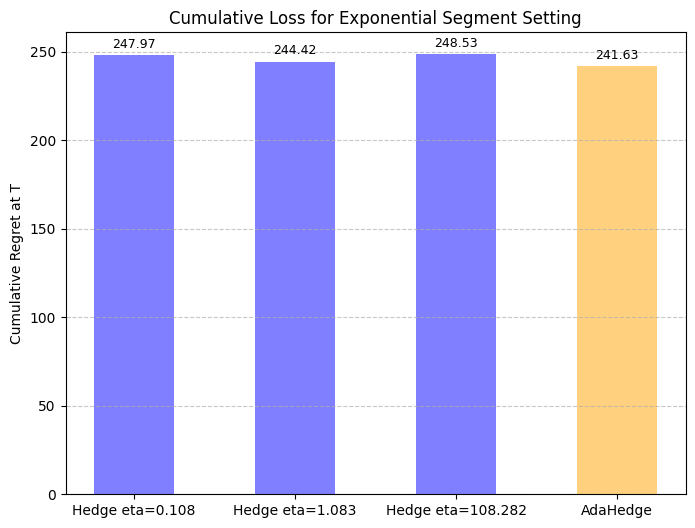

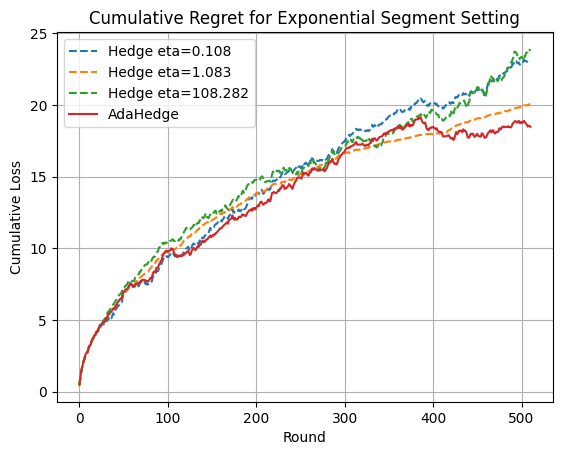

In [149]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(exponential_segment_setting, etas)
print("Average eta for AdaHedge in exponential segment setting:", AdaEta)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Exponential Segment Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(exponential_segment_setting, etas)

plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Exponential Segment Setting")